# <center>Do Arsenal have a disadvantage when it's raining?</center>

#### You may have seen the clip of TY, Arsenal Fan and AFTV contributor, using the statement "It's been raining" to excuse his team's poor performance during a 2-1 home loss to Watford. 

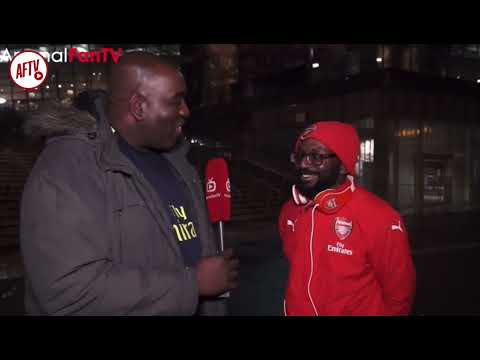

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo('j7mxHUueoVY')

Within the clip itself, and afterwards across the internet, TY was mocked for his claim. After all, as AFTV founder Robbie says in the clip, "It's raining for both teams!". 

Football, however, is a complex game, with a huge number of variables controlling the outcome of each match. Football score prediction is an industry in and of itself, with various sites, pundits and psychic Octopuses making predictions with varying levels of accuracy. Part of the reason the game is so beloved is its inherent unpredictability, with huge upsets meaning even the best team are never guaranteed to win. Sports betting companies pump huge amount of money into predictive models, and yet even they don't foresee certain outcomes, the most memorable consequence perhaps being the 5000/1 odds offered for Leicester City's ultimately successful attempt at becoming Premier League Champions in the 2015/16 season.

All of this is to say that football is difficult to predict. Is it likely that Arsenal are negatively affected by rain, despite the team they're up against obviously playing in the same conditions during the match? *Probably* not. But why not analyse the data to make sure?

## Initial Data

Football data is sourced from https://www.kaggle.com/datasets/marcohuiii/english-premier-league-epl-match-data-2000-2025/data.
Weather data is sourced from https://www.kaggle.com/datasets/zongaobian/london-weather-data-from-1979-to-2023/data. 

Sadly, Premier League stadiums do not tend to have weather stations attached, and so we'll have to use data from the nearest weather stations we can find. This introduces an element of variance, as different stadiums will be different distances from their nearest weather stations. To avoid this, we'll only focus on home matches, so that the distance to the nearest weather station (Heathrow) is constant (about 25.5km from Heathrow to the Emirates Stadium). This also means we don't need to consider the home field advantage, a well documented phenomenon where teams tend to perform better at home. This also means we do not need to control for the difference in home field advantage during the Coronavirus pandemic, when teams played without fans in the stadium[1].

I will discuss shortcomings of the datasets later when evaluating overall approach, but one drawback is so significant that it is worth mentioning now. The Heathrow Weather Station data only provides daily, not hourly, precipitation data. That means, in the worst case, that all of the rainfall could have occurred hours after the match in question, meaning we're considering a completely dry match to be 'rainy'. Unfortunately, there is no good way to account for this without more detailed data, and all observations made hereafter will have to be considered within this context. 

To begin with, let's look at Arsenal's home games in the 2016/17 season, as that's when the claim was made. 

### Arsenal 2016/17

In [196]:
import pandas as pd
import matplotlib.pyplot as plt

def highlight_wld(data):
    """
    For use with pandas table styler to colour matches depending on result
    """
    home, away = data.split("-")
    if home > away:
        return "background-color:greenyellow;"
    elif home == away:
        return "background-color:grey;"
    else:
        return "background-color:crimson;"

def drawTable(styler, caption):
    """
    Draw season results and rain data nicely
    """
    styler.set_caption(caption).set_table_styles([{
    'selector': 'caption',
    'props': [
        ('font-size', '16px'),
        ('font-weight', 'bold')
    ]}])
    styler.format({"Daily Rainfall (0.1mm)": "{:.0f}"})
    styler.map(highlight_wld, subset=["Score"])
    styler.background_gradient(axis=None, vmin=0, vmax=54, cmap="Blues")    
    return styler

    
df1 = pd.read_csv('Arsenal1617RainData.csv')
df1.style.pipe(drawTable, "Table 1 - Arsenal Record 2016/17")

,Season,AwayTeam,Score,Daily Rainfall (0.1mm)
0,2016/17,Liverpool,3-4,0
1,2016/17,Southampton,2-1,32
2,2016/17,Chelsea,3-0,16
3,2016/17,Swansea,3-2,78
4,2016/17,Middlesbrough,0-0,0
5,2016/17,Tottenham,1-1,16
6,2016/17,Bournemouth,3-1,0
7,2016/17,Stoke,3-1,44
8,2016/17,West Brom,1-0,0
9,2016/17,Crystal Palace,2-0,64


Table 1 contains the results and daily precipitation for each Arsenal match of the 2016/2017 season. Even at a glance, it doesn't look good for TY's claim. While admittedly, Arsenal did lose the Watford match while it was raining, the only other home loss they had that season occurred on a day with no rain at all. In addition, Arsenal managed to win on each of the 5 days with more precipitation, beating Sunderland, Swansea, Crystal Palace, Stoke and Southampton. 

In [64]:
df1 = df1.sort_values('Daily Rainfall (0.1mm)')
df1.style.pipe(drawTable, "Table 2 - Arsenal Record 2016/17 by rainfall")

,Season,AwayTeam,Score,Daily Rainfall (0.1mm)
0,2016/17,Liverpool,3-4,0
4,2016/17,Middlesbrough,0-0,0
6,2016/17,Bournemouth,3-1,0
8,2016/17,West Brom,1-0,0
13,2016/17,Man City,2-2,0
14,2016/17,West Ham,3-0,0
10,2016/17,Burnley,2-1,0
16,2016/17,Man United,2-0,0
18,2016/17,Everton,3-1,0
12,2016/17,Hull,2-0,8


Sorting the data by rainfall tells much the same story, with no real trend becoming apparent, and wins scattered across the entire range of rainfall values. However, we're only looking here at 19 data points, which is not enough to be able to draw any solid conclusion. Let's expand our analysis in the hope that we can find a clearer trend. 

## Further Data

Due to problems in the data I was able to source, the useful set of data is somewhat restricted. The Premier League data is missing some matches for the 2003/04, 2004/05 and 2023/24 seasons, and the weather data only goes up until the end of 2023. Therefore we will consider matches in the 2005/06 to 2022/23 seasons only, as the data for these can be considered complete.

This is still quite a small amount of data: only 323 games. While it would be ideal to have hundreds of home matches per season to analyse, this would likely make Arsenal's injury crisis even worse, so we'll have to make do. We could include FA Cup, League Cup and Champions League matches for more data, but given that these games have different contexts I believe it would likely introduce more unknown variables related to team mentality and tactical planning.  

The first thing to note with this expanded data set is that it is mainly made up of data taken at zero or very low levels of rainfall. 160 of the matches took place on days with 0mm of recorded precipitation. As can be seen in Figure 1, higher levels of precipitation account for very few of the data points. Therefore, it is not worth undertaking analysis of many different levels or rain, as at the higher levels we'd again be dealing with very small datasets unsuited to drawing any relevant conclusions.

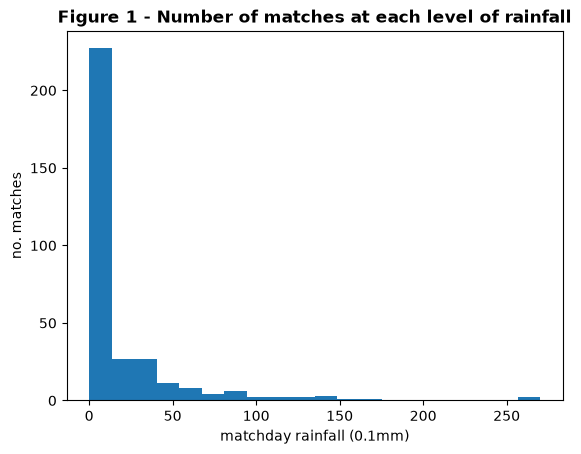

In [233]:
df3 = pd.read_csv('FullArsenalHomeRainData.csv')
plt.hist(df3["Daily Rainfall (0.1mm)"], 20)
plt.title("Figure 1 - Number of matches at each level of rainfall", fontweight='bold')
plt.xlabel("matchday rainfall (0.1mm)")
plt.ylabel("no. matches")
plt.show()

Instead, we'll define a level of rainfall above which we consider a match to be 'rainy'. Due to the aforementioned drawbacks with our dataset, namely, that the weather data is not for the stadium itself but for a weather station a significant distance away, and that the data covers the whole day instead of just the time of the match, this level needs to be relatively high, in order to have any confidence that the recorded rainfall could have influenced the match at all. The Met Office defines "slight rain" as rainfall with rates of accumulation up to 0.5mm/h, and "moderate rain" as those between 0.5mm/h and 4mm/h[2]. Expanding this to the whole day, it seems reasonable to set our definition of a "rainy match" as any match occurring on a day with a precipitation equal to or above 12mm/day. This should give us a reasonable chance of the match itself having occurred under rainy conditions, given it is equivalent to moderate rain throughout the entire 24 hour period.

In [222]:
def wld_string(data):
    """
    Returns W/D/L depending on result
    """
    home, away = data.split("-")
    if home > away:
        return "W"
    elif home == away:
        return "D"
    else:
        return "L"

df3['result'] = df3['Score'].apply(lambda x: wld_string(x))
rainy_data = df3[df3["Daily Rainfall (0.1mm)"] >=120]
dry_data = df3[df3["Daily Rainfall (0.1mm)"] < 120]

rainy_matches = len(rainy_data)
rainy_wins = len(rainy_data.query("result=='W'"))
rainy_draws = len(rainy_data.query("result=='D'"))
rainy_losses = len(rainy_data.query("result=='L'"))

dry_matches = len(dry_data)
dry_wins = len(dry_data.query("result=='W'"))
dry_draws = len(dry_data.query("result=='D'"))
dry_losses = len(dry_data.query("result=='L'"))

df4 = pd.DataFrame(
    [[rainy_matches, rainy_wins, (rainy_wins/rainy_matches)*100, rainy_draws, (rainy_draws/rainy_matches)*100, rainy_losses, (rainy_losses/rainy_matches)*100],
     [dry_matches, dry_wins, (dry_wins/dry_matches)*100, dry_draws, (dry_draws/dry_matches)*100, dry_losses, (dry_losses/dry_matches)*100]],
     index = ['Wet', 'Dry'],
    columns = ['no. matches', 'wins', '%wins', 'draws', '%draws', 'losses', '%losses']
)

df4.style.set_caption("Table 3 - Arsenal's results in different weather conditions, where wet = precipitation >= 12mm/day").set_table_styles([{
    'selector': 'caption',
    'props': [
        ('font-size', '16px'),
        ('font-weight', 'bold')
    ]}]).format(precision=2)

,no. matches,wins,%wins,draws,%draws,losses,%losses
Wet,9,5,55.56,2,22.22,2,22.22
Dry,314,206,65.61,66,21.02,42,13.38


As can be seen in Table 3 however, this presents another problem. The dataset is too small for this precipitation cutoff point to leave us with a significant number of "rainy matches" to analyse. With only 2 losses, observations are going to be skewed massively by each match.

Instead, we'll set the boundary at 2.5mm/h. This only corresponds to 5 hours of moderate rain a day in the best circumstances, and represents rain over an even smaller period of time if the rainfall was heavier. Ideally we would set the boundary to be a lot higher in order to have more confidence that rain affected the match, but this boundary already gives us only 70 rainy matches. Due to the quality of the data, we are again forced to make sacrifices.

In [224]:
rainy_data = df3[df3["Daily Rainfall (0.1mm)"] >=25]
dry_data = df3[df3["Daily Rainfall (0.1mm)"] < 25]

rainy_matches = len(rainy_data)
rainy_wins = len(rainy_data.query("result=='W'"))
rainy_draws = len(rainy_data.query("result=='D'"))
rainy_losses = len(rainy_data.query("result=='L'"))

dry_matches = len(dry_data)
dry_wins = len(dry_data.query("result=='W'"))
dry_draws = len(dry_data.query("result=='D'"))
dry_losses = len(dry_data.query("result=='L'"))

df4 = pd.DataFrame(
    [[rainy_matches, rainy_wins, (rainy_wins/rainy_matches)*100, rainy_draws, (rainy_draws/rainy_matches)*100, rainy_losses, (rainy_losses/rainy_matches)*100],
     [dry_matches, dry_wins, (dry_wins/dry_matches)*100, dry_draws, (dry_draws/dry_matches)*100, dry_losses, (dry_losses/dry_matches)*100]],
     index = ['Wet', 'Dry'],
    columns = ['no. matches', 'wins', '%wins', 'draws', '%draws', 'losses', '%losses']
)

df4.style.set_caption("Table 4 - Arsenal's results in different weather conditions, where wet = precipitation >= 2.5mm/day").set_table_styles([{
    'selector': 'caption',
    'props': [
        ('font-size', '16px'),
        ('font-weight', 'bold')
    ]}]).format(precision=2)

,no. matches,wins,%wins,draws,%draws,losses,%losses
Wet,70,46,65.71,15,21.43,9,12.86
Dry,253,165,65.22,53,20.95,35,13.83


Now we've got our data, we can attempt some analysis, and immediately, TY's claim again seems unfounded. Not only do the win and loss percentages barely differ between the two weather conditions, but by a small margin Arsenal actually won at higher rate, and lost at at lower rate in the rainy matches. As can be seen in Figure 2, the pie charts for each are practically identical. 

Using the data we have, we have not been able to prove TY's claim. 

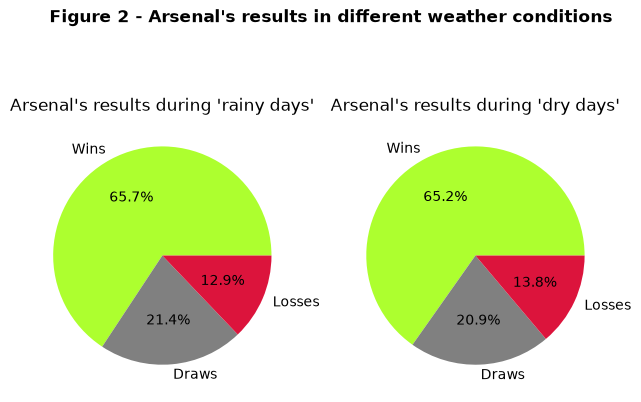

In [225]:
fig, (ax1, ax2) = plt.subplots(1,2)
fig.suptitle("Figure 2 - Arsenal's results in different weather conditions", fontweight='bold')
ax1.pie([rainy_wins, rainy_draws, rainy_losses], labels=['Wins', 'Draws', 'Losses'], autopct='%1.1f%%', colors=["greenyellow","grey","crimson"])
ax1.set_title("Arsenal's results during 'rainy days'")

ax2.pie([dry_wins, dry_draws, dry_losses], labels=['Wins', 'Draws', 'Losses'], autopct='%1.1f%%', colors=["greenyellow","grey","crimson"])
ax2.set_title("Arsenal's results during 'dry days'")

plt.tight_layout()
plt.show()

### Other observations
As can be seen in Table 5, the Arsenal's 2016/17 home match against Watford was not the only time the two teams clashed at the Emirates, but it was the only home match in which Arsenal lost. The other matches all took place at either a lower level of daily precipitation, or a higher level. Using only this data, claiming rain affected the result of the 2016/17 is completely unfounded. 

In [226]:
df2 = pd.read_csv('ArsenalvWatfordRainData.csv')
df2.style.pipe(drawTable, "Table 5 - Arsenal Record vs Watford 2006/7 to 2022/2023")

,Season,AwayTeam,Score,Daily Rainfall (0.1mm)
0,2006/07,Watford,3-0,0
1,2015/16,Watford,4-0,32
2,2016/17,Watford,1-2,28
3,2017/18,Watford,3-0,54
4,2018/19,Watford,2-0,0
5,2019/20,Watford,3-2,40
6,2021/22,Watford,1-0,0


## Conclusion and Evaluation

Using the data we have collected, and within the confines of the parameters we have set out, any difference in win rate for each weather condition is far too minimal to prove that Arsenal have any sort of advantage or disadvantage when its raining during the match. I would argue however that given the numerous flaws in our dataset, we have also been unable to conclusively disprove the claim. 

Our dataset is small, the weather data is not from a location particularly close to the stadium, and it does not accurately tell us if rain affected the match we are interested in. In order to evaluate this claim more robustly, we would need better data. An ideal dataset would have weather data at the location of every match, at the time at which the match was played. It would also have more detailed information on other variables that could affect team performance: it may be necessary to consider some matches to be outliers, if for example key team members were injured, or other major changes affected the team's ability. 

However, even with this ideal dataset, any analysis is going to have some holes as a reflection of the nature of football: teams can only play a finite number of games per season; teams change players, tactics and managers frequently, so it may not be useful to compare a team across two consecutive seasons, let alone across dozens; home field advantage is difficult to quantify, but attempting to negate it cuts any dataset in half. Using the final score as a metric for Arsenal's success is perhaps not the best approach. For example, Expected Goals is a commonly used measure which claims to "assess team and player performances far more accurately" than other statistical metrics [3].

### Citations

[1] Leitner MC, Daumann F, Follert F, Richlan F. The cauldron has cooled down: a systematic literature review on home advantage in football during the COVID-19 pandemic from a socio-economic and psychological perspective. Manag Rev Q. 2023;73(2):605–33. doi: 10.1007/s11301-021-00254-5. Epub 2022 Jan 4. PMCID: PMC8724651.

[2]https://www.metoffice.gov.uk/binaries/content/assets/metofficegovuk/pdf/research/library-and-archive/library/publications/factsheets/factsheet_3-water-in-the-atmosphere_2023.pdf

[3]Anzer G, Bauer P. A Goal Scoring Probability Model for Shots Based on Synchronized Positional and Event Data in Football (Soccer). Front Sports Act Living. 2021 Mar 29;3:624475. doi: 10.3389/fspor.2021.624475. PMID: 33889843; PMCID: PMC8056301.